# **Diminos Store - Delivery Time Analysis**

Importing Libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

Loading the Data

In [24]:
df =pd.read_csv("diminos_data.csv")
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [25]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])

In [26]:
df['delivery_time_mins'] = (
    df['order_delivered_at'] - df['order_placed_at']
).dt.total_seconds()/60

df.head()

,order_id,order_placed_at,order_delivered_at,delivery_time_mins
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984


Data Validation

In [27]:
df[df['delivery_time_mins'] <=0]

,order_id,order_placed_at,order_delivered_at,delivery_time_mins


Core Metrics

In [28]:
mean_time = df['delivery_time_mins'].mean()
median_time = df['delivery_time_mins'].median()
p95_time = df['delivery_time_mins'].quantile(0.95)
on_time_rate = (df['delivery_time_mins'] <= 31).mean()*100

In [29]:
print(f"Avg Delivery Time: {mean_time:.2f} mins")
print(f"Median Delivery Time: {median_time:.2f} mins")
print(f"95th Percentile Delivery Time: {p95_time:.2f} mins")
print(f"Orders Delivered within 31 mins: {on_time_rate:.2f}%")

Avg Delivery Time: 20.50 mins
Median Delivery Time: 15.80 mins
95th Percentile Delivery Time: 27.26 mins
Orders Delivered within 31 mins: 96.29%


**Visual Analysis**

Delivery Time Distribution

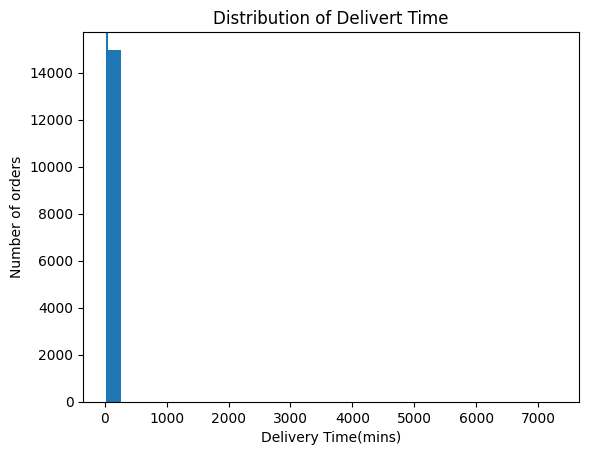

In [30]:
plt.figure()
plt.hist(df['delivery_time_mins'], bins=30)
plt.axvline(31)
plt.xlabel("Delivery Time(mins)")
plt.ylabel("Number of orders")
plt.title("Distribution of Delivert Time")
plt.show()

Boxplot

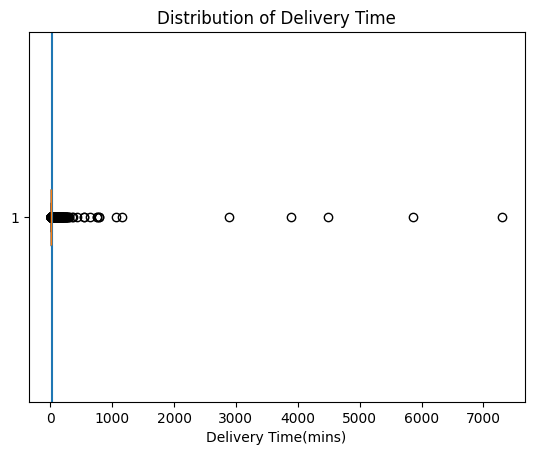

In [32]:
plt.figure()
plt.boxplot(df['delivery_time_mins'], vert=False)
plt.axvline(31)
plt.xlabel("Delivery Time(mins)")
plt.title("Distribution of Delivery Time")
plt.show()

Hourly Performances

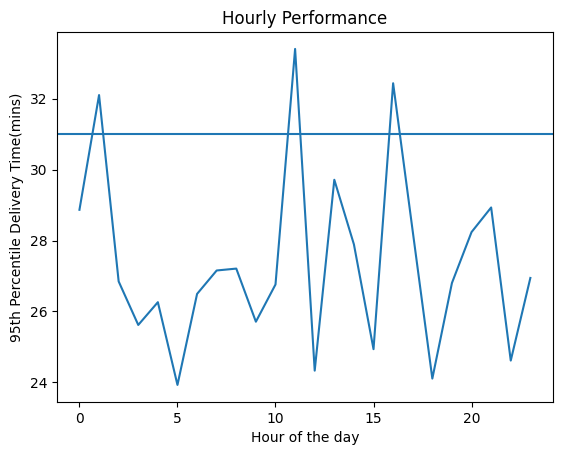

In [33]:
df['order_hour'] = df['order_placed_at'].dt.hour

hourly_p95 = df.groupby('order_hour')['delivery_time_mins'].quantile(0.95)

plt.figure()
hourly_p95.plot()
plt.axhline(31)
plt.xlabel("Hour of the day")
plt.ylabel("95th Percentile Delivery Time(mins)")
plt.title("Hourly Performance")
plt.show()

Final Check

In [34]:
if p95_time <31:
  print("Store is compliant with Diminos standards.")
else:
  print("Store is not compliant with Diminos standards.")

Store is compliant with Diminos standards.
